Loading landmark data...
Loaded 212 landmark frames
Loading clip ranges...
Loaded 8 clip segments
Loading contact/separation annotations...
Loaded 8 contact/separation pairs

=== Annotation Validation ===
Clip ranges: 8 entries
CS annotations: 8 entries
✅ Clip 1: Contact 92, Separation 111 (within 79-120)
✅ Clip 2: Contact 137, Separation 155 (within 127-164)
✅ Clip 3: Contact 179, Separation 206 (within 172-215)
✅ Clip 4: Contact 231, Separation 251 (within 223-262)
✅ Clip 5: Contact 282, Separation 303 (within 272-309)
✅ Clip 6: Contact 331, Separation 344 (within 321-353)
✅ Clip 7: Contact 370, Separation 392 (within 363-402)
✅ Clip 8: Contact 417, Separation 442 (within 408-450)

Processing landmarks by clips with tangential acceleration...
Clip 1 (79-120): Found 32 landmark frames
Clip 2 (127-164): Found 26 landmark frames
Clip 3 (172-215): Found 32 landmark frames
Clip 4 (223-262): Found 22 landmark frames
Clip 5 (272-309): Found 29 landmark frames
Clip 6 (321-353): Found 23 land

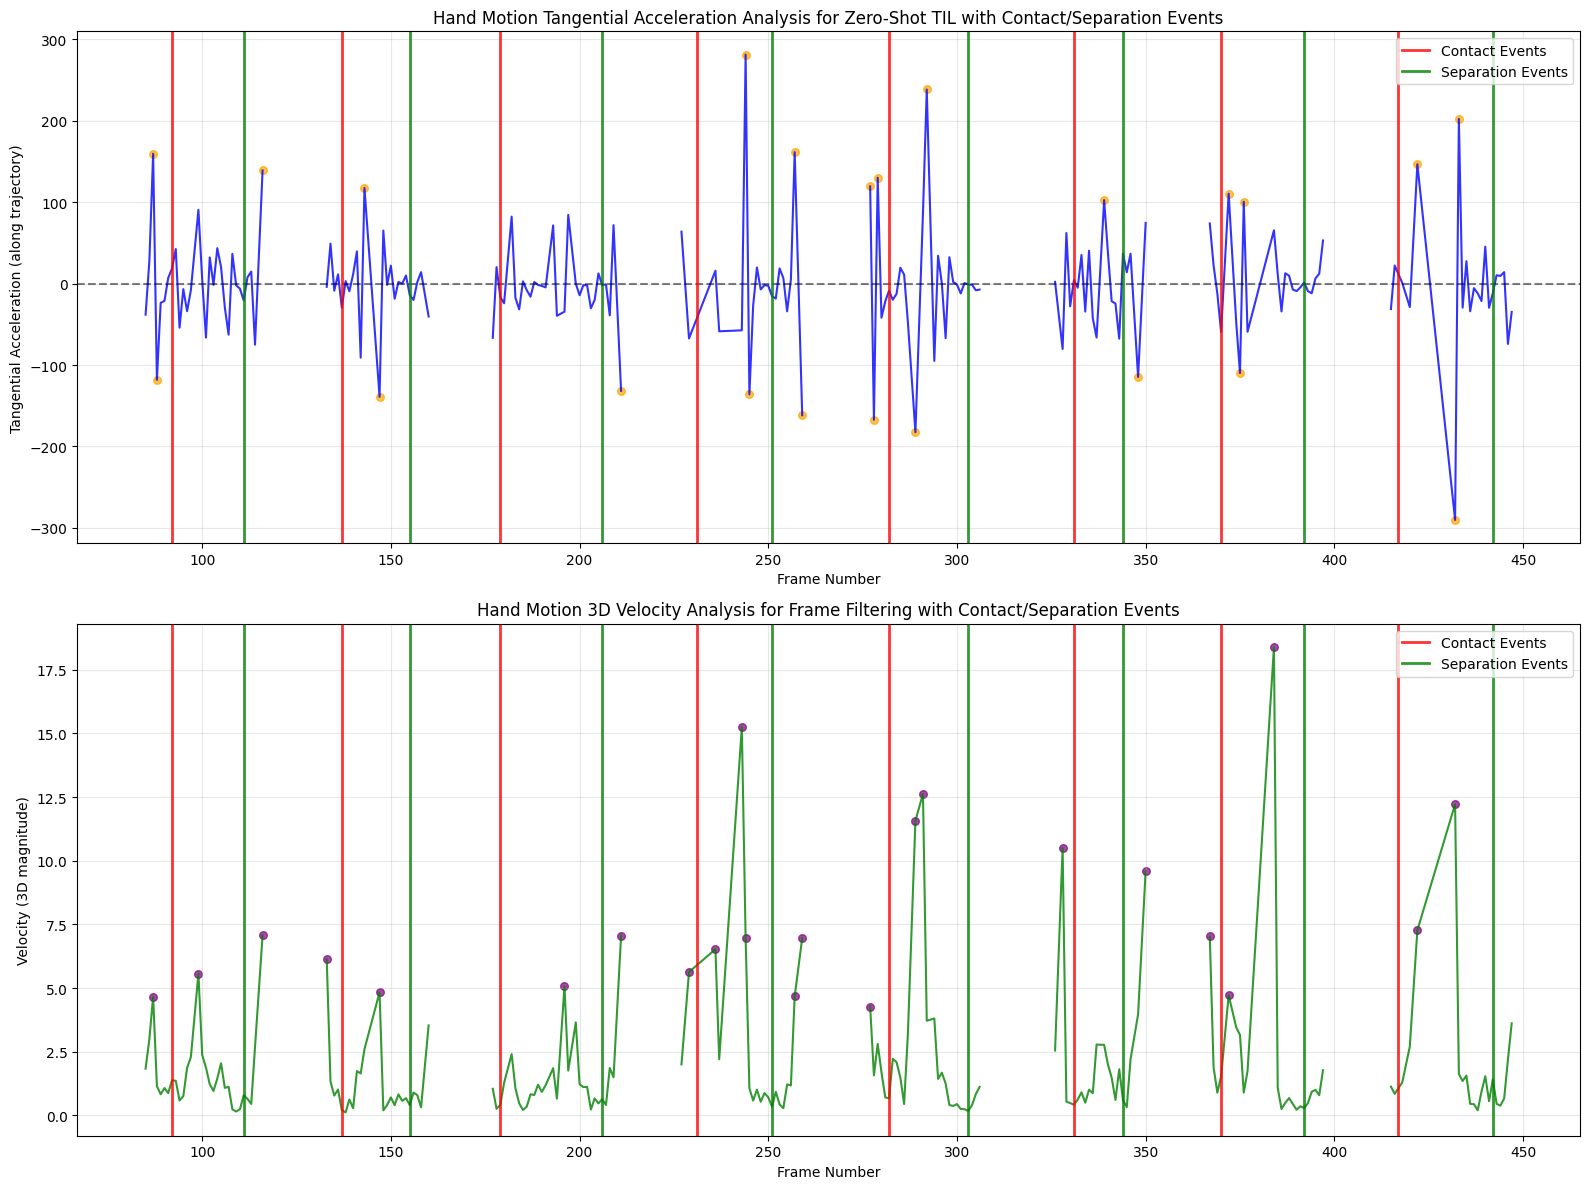


=== Tangential Acceleration-Based Frame Filtering Insights ===
Total frames analyzed: 196
Tangential acceleration range: -290.24 to 281.09
3D Velocity range: 0.11 to 18.39
High-motion tangential acceleration threshold: 97.88
High-motion velocity threshold: 4.00
High-motion frames for filtering: 34 (17.3%)

=== Contact/Separation Tangential Acceleration Analysis ===
Clip 1: Contact-to-Separation duration = 19 frames
Clip 2: Contact-to-Separation duration = 18 frames
Clip 3: Contact-to-Separation duration = 27 frames
Clip 4: Contact-to-Separation duration = 20 frames
Clip 5: Contact-to-Separation duration = 21 frames
Clip 6: Contact-to-Separation duration = 13 frames
Clip 7: Contact-to-Separation duration = 22 frames
Clip 8: Contact-to-Separation duration = 25 frames


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import re


def parse_landmarks_file(filename):
    """Parse the landmarks file and extract frame numbers and coordinates."""
    landmarks_data = {}
    
    with open(filename, 'r') as file:
        content = file.read()
        
    frame_blocks = re.split(r'(\d+):', content)
    
    for i in range(1, len(frame_blocks), 2):
        frame_num = int(frame_blocks[i])
        landmark_block = frame_blocks[i + 1]
        
        x_match = re.search(r'x:\s*([-+]?\d*\.?\d+)', landmark_block)
        y_match = re.search(r'y:\s*([-+]?\d*\.?\d+)', landmark_block)
        z_match = re.search(r'z:\s*([-+]?\d*\.?\d+)', landmark_block)
        
        if x_match and y_match and z_match:
            landmarks_data[frame_num] = {
                'x': float(x_match.group(1)),
                'y': float(y_match.group(1)),
                'z': float(z_match.group(1))
            }
    
    return landmarks_data


def parse_clip_ranges(filename):
    """Parse clip ranges file with robust error handling."""
    clip_ranges = []
    
    with open(filename, 'r') as file:
        lines = file.readlines()
        
    for line_num, line in enumerate(lines, 1):
        line = line.strip()
        if not line:  # Skip empty lines
            continue
            
        # Match pattern "number. start_frame, end_frame"
        match = re.search(r'\d+\.\s*(\d+),\s*(\d+)', line)
        if match:
            start_frame = int(match.group(1))
            end_frame = int(match.group(2))
            clip_ranges.append((start_frame, end_frame))
        else:
            print(f"Warning: Could not parse line {line_num}: '{line}'")
    
    return clip_ranges


def parse_cs_annot(filename):
    """Parse contact and separation annotations with robust error handling."""
    cs_annotations = []
    
    with open(filename, 'r') as file:
        lines = file.readlines()
        
    for line_num, line in enumerate(lines, 1):
        line = line.strip()
        if not line:  # Skip empty lines
            continue
            
        # Match pattern "index. contact, separation"
        match = re.search(r'\d+\.\s*(\d+),\s*(\d+)', line)
        if match:
            contact = int(match.group(1))
            separation = int(match.group(2))
            cs_annotations.append((contact, separation))
        else:
            print(f"Warning: Could not parse line {line_num}: '{line}'")
    
    return cs_annotations


def validate_annotations(clip_ranges, cs_annotations):
    """Validate that contact/separation frames are within clip boundaries."""
    print(f"\n=== Annotation Validation ===")
    print(f"Clip ranges: {len(clip_ranges)} entries")
    print(f"CS annotations: {len(cs_annotations)} entries")
    
    if len(clip_ranges) != len(cs_annotations):
        print(f"⚠️  MISMATCH: {len(clip_ranges)} clips vs {len(cs_annotations)} annotations")
        return False
    
    validation_passed = True
    for i, ((start, end), (contact, separation)) in enumerate(zip(clip_ranges, cs_annotations)):
        clip_num = i + 1
        
        # Check if contact is within clip range
        if not (start <= contact <= end):
            print(f"❌ Clip {clip_num}: Contact frame {contact} outside range ({start}-{end})")
            validation_passed = False
        
        # Check if separation is within clip range
        if not (start <= separation <= end):
            print(f"❌ Clip {clip_num}: Separation frame {separation} outside range ({start}-{end})")
            validation_passed = False
        
        # Check if contact comes before separation
        if contact >= separation:
            print(f"❌ Clip {clip_num}: Contact {contact} should be before separation {separation}")
            validation_passed = False
        
        if validation_passed:
            print(f"✅ Clip {clip_num}: Contact {contact}, Separation {separation} (within {start}-{end})")
    
    return validation_passed


from typing import List, Tuple
import numpy as np

def calculate_hand_acceleration_magnitude(
    landmarks: List[dict], fps: int = 30
) -> Tuple[List[float], List[float]]:
    """
    Amplified-Z acceleration for zero-shot TIL frame filtering.
    
    1.  Compute frame-to-frame 3-D velocities and raw 3-D accelerations.
    2.  Weight the z-component so that it dominates when |a_z| ≫ |a_x|,|a_y|,
        but is suppressed when all three components are similar.
        a_z_amp = sign(a_z) · (|a_z| / (|a_x|+|a_y|+|a_z|))^γ · |a_z|
        (γ ≥1, use γ=2 for strong boost).
    3.  Return
        • amplified signed z-acceleration series  (length N-2, aligned with frames[2:])
        • 3-D speed magnitudes at the same frames (|v| from vel[1:])
    
    Parameters
    ----------
    landmarks : list of dicts with keys 'x','y','z' (one per frame)
    fps       : frames per second (default 30)
    
    Returns
    -------
    az_amp    : List[float]   – weighted, sign-preserving z-acceleration
    speed_mag : List[float]   – 3-D speed magnitudes, alignment match
    """
    if len(landmarks) < 3:
        return [], []

    # --- positions & timestep -------------------------------------------------
    pos = np.array([[lm['x'], lm['y'], lm['z']] for lm in landmarks])
    dt  = 1.0 / fps

    # --- velocities (N-1,3) ---------------------------------------------------
    vel = np.diff(pos, axis=0) / dt

    # --- raw accelerations (N-2,3) -------------------------------------------
    acc = np.diff(vel, axis=0) / dt
    ax, ay, az = acc[:, 0], acc[:, 1], acc[:, 2]

    # --- z-dominance weighting (γ = 2 gives strong amplification) -------------
    gamma = 2.0
    denom = np.abs(ax) + np.abs(ay) + np.abs(az) + 1e-9   # avoid zero-div
    r     = np.abs(az) / denom                            # 0..1 dominance ratio
    az_amp = np.sign(az) * (r ** gamma) * np.abs(az)      # amplified, sign-preserved

    # --- 3-D speed magnitudes aligned with az_amp -----------------------------
    speed_mag = np.linalg.norm(vel[1:], axis=1)           # vel[1:] aligns with acc

    return az_amp.tolist(), speed_mag.tolist()


def process_landmarks_by_clips(landmarks_data, clip_ranges, fps=30):
    """Process landmarks by clips with tangential acceleration analysis."""
    clip_data = []
    
    for clip_idx, (start_frame, end_frame) in enumerate(clip_ranges):
        clip_frames = []
        clip_landmarks = []
        
        for frame_num in sorted(landmarks_data.keys()):
            if start_frame <= frame_num <= end_frame:
                clip_frames.append(frame_num)
                clip_landmarks.append(landmarks_data[frame_num])
        
        print(f"Clip {clip_idx + 1} ({start_frame}-{end_frame}): Found {len(clip_landmarks)} landmark frames")
        
        if len(clip_landmarks) >= 3:
            # Use tangential acceleration
            accelerations, velocities = calculate_hand_tangential_acceleration(clip_landmarks, fps)
            
            # Acceleration starts from frame 2 in the clip
            accel_frames = clip_frames[2:]
            # Velocities are already aligned with acceleration frames
            
            clip_data.append({
                'frames': accel_frames,
                'velocities': velocities,
                'accelerations': accelerations,
                'clip_range': (start_frame, end_frame),
                'clip_index': clip_idx
            })
        else:
            print(f"⚠️  Clip {clip_idx + 1}: Not enough landmarks for motion analysis")
    
    return clip_data


def create_disjoint_motion_plots_with_annotations(clip_data, cs_annotations):
    """Create disjoint plots with tangential acceleration for zero-shot TIL research."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))
    
    # Plot TANGENTIAL acceleration with disjoint segments
    all_accelerations = []
    for i, clip in enumerate(clip_data):
        ax1.plot(clip['frames'], clip['accelerations'], 'b-', 
                linewidth=1.5, alpha=0.8)
        all_accelerations.extend(clip['accelerations'])
    
    ax1.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax1.set_xlabel('Frame Number')
    ax1.set_ylabel('Tangential Acceleration (along trajectory)')
    ax1.set_title('Hand Motion Tangential Acceleration Analysis for Zero-Shot TIL with Contact/Separation Events')
    ax1.grid(True, alpha=0.3)
    
    # Add ONLY contact and separation lines with legends
    contact_label_added = False
    separation_label_added = False
    
    # Use min length to avoid index errors
    annotation_count = min(len(clip_data), len(cs_annotations))
    print(f"\nAdding annotations for {annotation_count} clips")
    
    for i in range(annotation_count):
        contact, separation = cs_annotations[i]
        
        # Add labels only once for legend
        if not contact_label_added:
            ax1.axvline(x=contact, color='red', linestyle='-', alpha=0.8, linewidth=2,
                       label='Contact Events')
            contact_label_added = True
        else:
            ax1.axvline(x=contact, color='red', linestyle='-', alpha=0.8, linewidth=2)
        
        if not separation_label_added:
            ax1.axvline(x=separation, color='green', linestyle='-', alpha=0.8, linewidth=2,
                       label='Separation Events')
            separation_label_added = True
        else:
            ax1.axvline(x=separation, color='green', linestyle='-', alpha=0.8, linewidth=2)
    
    # Highlight high tangential acceleration regions WITHOUT legend
    if all_accelerations:
        high_accel_threshold = np.std(all_accelerations) * 1.5
        for clip in clip_data:
            high_indices = [i for i, acc in enumerate(clip['accelerations']) 
                          if abs(acc) > high_accel_threshold]
            if high_indices:
                high_frames = [clip['frames'][i] for i in high_indices]
                high_values = [clip['accelerations'][i] for i in high_indices]
                ax1.scatter(high_frames, high_values, c='orange', s=30, alpha=0.7)
    
    # Show ONLY Contact/Separation legends
    ax1.legend(loc='upper right')
    
    # Plot velocity with disjoint segments
    all_velocities = []
    for i, clip in enumerate(clip_data):
        ax2.plot(clip['frames'], clip['velocities'], 'g-', 
                linewidth=1.5, alpha=0.8)
        all_velocities.extend(clip['velocities'])
    
    ax2.set_xlabel('Frame Number')
    ax2.set_ylabel('Velocity (3D magnitude)')
    ax2.set_title('Hand Motion 3D Velocity Analysis for Frame Filtering with Contact/Separation Events')
    ax2.grid(True, alpha=0.3)
    
    # Add ONLY contact and separation lines for velocity plot
    contact_label_added = False
    separation_label_added = False
    
    for i in range(annotation_count):
        contact, separation = cs_annotations[i]
        
        if not contact_label_added:
            ax2.axvline(x=contact, color='red', linestyle='-', alpha=0.8, linewidth=2,
                       label='Contact Events')
            contact_label_added = True
        else:
            ax2.axvline(x=contact, color='red', linestyle='-', alpha=0.8, linewidth=2)
        
        if not separation_label_added:
            ax2.axvline(x=separation, color='green', linestyle='-', alpha=0.8, linewidth=2,
                       label='Separation Events')
            separation_label_added = True
        else:
            ax2.axvline(x=separation, color='green', linestyle='-', alpha=0.8, linewidth=2)
    
    # Highlight high velocity regions WITHOUT legend
    if all_velocities:
        high_vel_threshold = np.std(all_velocities) * 1.5
        for clip in clip_data:
            high_indices = [i for i, vel in enumerate(clip['velocities']) 
                          if vel > high_vel_threshold]
            if high_indices:
                high_frames = [clip['frames'][i] for i in high_indices]
                high_values = [clip['velocities'][i] for i in high_indices]
                ax2.scatter(high_frames, high_values, c='purple', s=30, alpha=0.7)
    
    # Show ONLY Contact/Separation legends
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return fig


def main():
    """Main function with tangential acceleration analysis for zero-shot TIL research."""
    landmarks_file = "../test_data/5th_landmarks_trimmed.txt"
    clip_ranges_file = "../test_data/clip_ranges_10.txt"
    cs_annot_file = "../test_data/cs_annot.txt"
    
    print("Loading landmark data...")
    landmarks_data = parse_landmarks_file(landmarks_file)
    print(f"Loaded {len(landmarks_data)} landmark frames")
    
    print("Loading clip ranges...")
    clip_ranges = parse_clip_ranges(clip_ranges_file)
    print(f"Loaded {len(clip_ranges)} clip segments")
    
    print("Loading contact/separation annotations...")
    cs_annotations = parse_cs_annot(cs_annot_file)
    print(f"Loaded {len(cs_annotations)} contact/separation pairs")
    
    # Validate annotations
    validation_passed = validate_annotations(clip_ranges, cs_annotations)
    if not validation_passed:
        print("⚠️  Validation failed, but continuing with analysis...")
    
    print("\nProcessing landmarks by clips with tangential acceleration...")
    clip_data = process_landmarks_by_clips(landmarks_data, clip_ranges, fps=30)
    
    print(f"\n=== Tangential Acceleration Motion Analysis Results ===")
    for i, clip in enumerate(clip_data):
        print(f"Clip {i+1} ({clip['clip_range'][0]}-{clip['clip_range'][1]}): "
              f"{len(clip['frames'])} frames with motion data")
    
    # Create enhanced plots with tangential acceleration annotations
    print("\n=== Creating Tangential Acceleration Plots for Zero-Shot TIL Research ===")
    fig = create_disjoint_motion_plots_with_annotations(clip_data, cs_annotations)
    
    # Generate insights for tangential acceleration-based frame filtering
    print("\n=== Tangential Acceleration-Based Frame Filtering Insights ===")
    
    total_frames = sum(len(clip['frames']) for clip in clip_data)
    all_accelerations = [acc for clip in clip_data for acc in clip['accelerations']]
    all_velocities = [vel for clip in clip_data for vel in clip['velocities']]
    
    if all_accelerations and all_velocities:
        accel_threshold = np.std(all_accelerations) * 1.5
        vel_threshold = np.std(all_velocities) * 1.5
        
        # Count high-motion frames for filtering insights
        high_motion_count = 0
        for clip in clip_data:
            for acc, vel in zip(clip['accelerations'], clip['velocities']):
                if abs(acc) > accel_threshold or vel > vel_threshold:
                    high_motion_count += 1
        
        print(f"Total frames analyzed: {total_frames}")
        print(f"Tangential acceleration range: {min(all_accelerations):.2f} to {max(all_accelerations):.2f}")
        print(f"3D Velocity range: {min(all_velocities):.2f} to {max(all_velocities):.2f}")
        print(f"High-motion tangential acceleration threshold: {accel_threshold:.2f}")
        print(f"High-motion velocity threshold: {vel_threshold:.2f}")
        print(f"High-motion frames for filtering: {high_motion_count} ({high_motion_count/total_frames*100:.1f}%)")
        
        # Analyze motion patterns around contact/separation events
        print(f"\n=== Contact/Separation Tangential Acceleration Analysis ===")
        for i, (contact, separation) in enumerate(cs_annotations):
            duration = separation - contact
            print(f"Clip {i+1}: Contact-to-Separation duration = {duration} frames")
    
    return {
        'clip_data': clip_data,
        'cs_annotations': cs_annotations,
        'landmarks_data': landmarks_data,
        'clip_ranges': clip_ranges,
        'validation_passed': validation_passed
    }


if __name__ == "__main__":
    results = main()
